# Session 1: 머신러닝 소개와 탐색적 데이터 분석 (EDA)

**대상**: ML 배경 없는 DevOps 엔지니어  
**프로젝트**: 2019 2nd ML month with KaKR - 집값 예측  

---

### 대회 배경

이 튜토리얼은 **[2019 2nd ML month with KaKR](https://www.kaggle.com/competitions/2019-2nd-ml-month-with-kakr)** Kaggle 컴피티션을 기반으로 합니다.

| 항목 | 내용 |
|------|------|
| **대회명** | 2019 2nd ML month with KaKR - House Price Prediction |
| **주최** | Google Korea 후원, Kaggle Korea (캐글 코리아) 주관 |
| **목적** | 학술 목적의 비영리 대회, 한국 내 누구나 참여 가능 |
| **과제** | 20개 변수를 활용하여 주택 가격을 예측하는 회귀 모델 구축 |
| **평가 지표** | RMSE (Root Mean Squared Error) |
| **참고 솔루션** | [11위 솔루션 커널](https://www.kaggle.com/tmheo74/11th-solution-public-98316-private-99336) |

주택 가격은 주거 면적, 위치, 조망, 건물 연식 등 다양한 요인에 의해 결정됩니다.
이 대회에서는 주어진 데이터를 분석하고 모델을 학습시켜 가격을 예측하는 것이 목표입니다.

---

## Part 1: 이론

### 1.1 머신러닝(ML)이란?

#### 규칙 기반 vs 데이터 기반 학습

**규칙 기반 (전통적 프로그래밍)**

개발자가 직접 규칙을 작성합니다.

```
if CPU사용률 > 90% and 지속시간 > 5분:
    알람 발생
elif 메모리사용률 > 85%:
    알람 발생
```

**데이터 기반 (머신러닝)**

과거 데이터에서 패턴을 학습하여 스스로 규칙을 만듭니다.

```
과거 장애 데이터 1000건 → 모델 학습 → 이상 탐지 규칙 자동 생성
```

#### DevOps 비유

| 구분 | 규칙 기반 (if-else) | 머신러닝 |
|------|---------------------|----------|
| 알람 설정 | CPU > 90%이면 알람 (사람이 임계값 설정) | 과거 장애 패턴을 학습하여 이상 징후 자동 감지 |
| 용량 계획 | 월 성장률 10% 가정하고 수동 계산 | 과거 트래픽 패턴을 학습하여 미래 사용량 예측 |
| 로그 분석 | 특정 에러 문자열 grep | 로그 패턴을 학습하여 비정상 로그 자동 분류 |

> **핵심**: 머신러닝은 "데이터에서 패턴을 찾아 예측하는 기술"입니다.  
> 규칙을 사람이 만드는 게 아니라, **데이터가 규칙을 만들어** 줍니다.

### 1.2 문제 유형: 분류 / 회귀 / 군집화

머신러닝 문제는 크게 세 가지로 나뉩니다.

| 유형 | 설명 | DevOps 예시 | 출력 |
|------|------|-------------|------|
| **분류 (Classification)** | 카테고리를 예측 | 이 로그는 정상/비정상? | 범주 (A, B, C) |
| **회귀 (Regression)** | 연속적인 숫자를 예측 | 내일 서버 트래픽은 몇 RPS? | 숫자 (3.14, 1000, ...) |
| **군집화 (Clustering)** | 비슷한 것끼리 그룹핑 | 비슷한 패턴의 서버들을 묶기 | 그룹 |

#### 이 프로젝트는 **회귀** 문제입니다

- **입력**: 집의 특성 (면적, 방 개수, 위치 등)
- **출력**: 집값 (연속적인 숫자)
- **목표**: 주어진 집 정보로 가격을 **정확하게 예측**하는 것

> **생각해보기**: DevOps에서 "내일 이 서버의 응답시간은 몇 ms일까?"를 예측하는 것도 회귀 문제입니다.

### 1.3 학습 유형: 지도학습 vs 비지도학습

머신러닝은 **정답(label)의 유무**에 따라 학습 방식이 달라집니다.

#### 지도학습 (Supervised Learning)

**정답이 있는 데이터**로 학습합니다. 1.2에서 배운 분류와 회귀가 여기에 해당합니다.

- 집값 예측: 입력(면적, 방 수) → 정답(price) → 모델이 패턴 학습
- 스팸 분류: 입력(메일 내용) → 정답(스팸/정상) → 모델이 판별 기준 학습

> **DevOps 비유**: 과거 장애 이력(원인 + 결과)으로 학습 → 새로운 알람이 오면 자동으로 원인 분류

#### 비지도학습 (Unsupervised Learning)

**정답 없이** 데이터의 패턴이나 구조를 발견합니다. 군집화가 대표적입니다.

- 고객 세그멘테이션: 구매 패턴이 비슷한 고객끼리 자동 그룹핑
- 이상 탐지: 정상 패턴에서 벗어나는 데이터를 자동 감지

> **DevOps 비유**: 서버 로그에서 비슷한 에러 패턴끼리 자동 그룹핑 → "이 에러들은 같은 원인일 가능성이 높다"

#### 비교 표

| 구분 | 지도학습 | 비지도학습 |
|------|----------|------------|
| **정답 유무** | 있음 (label) | 없음 |
| **목표** | 정답을 예측 | 패턴/구조 발견 |
| **대표 문제** | 분류, 회귀 | 군집화, 차원 축소 |
| **예시** | 집값 예측, 스팸 필터 | 고객 세분화, 이상 탐지 |
| **DevOps 예시** | 장애 원인 자동 분류 | 로그 패턴 자동 그룹핑 |

#### 이 프로젝트는 **지도학습 + 회귀** 문제입니다

- **지도학습**: 정답(price)이 주어진 train 데이터로 학습
- **회귀**: 연속적인 숫자(집값)를 예측

> **참고**: 이 외에도 **강화학습(Reinforcement Learning)**이 있습니다.  
> 시행착오를 통해 보상을 최대화하는 방식으로, 게임 AI나 로봇 제어에 사용됩니다.  
> 이 프로젝트에서는 다루지 않습니다.

### 1.4 데이터 유형: 정형 데이터 vs 비정형 데이터

머신러닝이 다루는 데이터는 크게 **정형 데이터**와 **비정형 데이터**로 나뉩니다.

#### 정형 데이터 (Structured / Tabular Data)

행과 열로 구성된 테이블 형태의 데이터입니다.
- 엑셀 스프레드시트, DB 테이블, CSV 파일
- 각 행은 하나의 데이터 포인트, 각 열은 하나의 특성(feature)

#### 비정형 데이터 (Unstructured Data)

고정된 구조 없이 다양한 형태로 존재하는 데이터입니다.
- 이미지, 영상, 음성, 자연어 텍스트

#### 딥러닝의 혁신과 비정형 데이터

딥러닝은 비정형 데이터 처리에 혁신을 가져왔습니다.
- **CNN**: 이미지 인식, 객체 탐지
- **RNN / Transformer**: 텍스트 번역, 음성 인식, 생성형 AI (ChatGPT 등)

하지만 **비즈니스 현장에서 다루는 데이터의 대부분은 여전히 정형 데이터**입니다.
매출 데이터, 고객 정보, 거래 내역, 재고 현황 등 기업의 핵심 의사결정에 사용되는 데이터는 거의 모두 테이블 형태입니다.

#### DevOps 비유

DevOps에서 다루는 데이터도 대부분 정형 데이터입니다.
- 서버 메트릭 (CPU, 메모리, 디스크 사용률)
- 로그 집계 (시간대별 에러 건수, 응답시간 통계)
- 비용 데이터 (인스턴스별 월 비용, 리전별 트래픽)

#### 정형 vs 비정형 비교

| 구분 | 정형 데이터 | 비정형 데이터 |
|------|------------|--------------|
| **데이터 형태** | 행과 열 (테이블) | 이미지, 텍스트, 음성 |
| **예시** | 매출 DB, 센서 로그, CSV | 사진, 이메일 본문, 녹음 파일 |
| **대표 모델** | XGBoost, LightGBM, Random Forest | CNN, Transformer, Diffusion |
| **비즈니스 활용도** | 매우 높음 (핵심 의사결정) | 높음 (특정 도메인) |

#### 이 프로젝트는 정형 데이터!

캐글 플랫폼에서는 정형 데이터 컴피티션이 활발하게 열리며, 이 튜토리얼의 강사도 정형 데이터 컴피티션에서 우수한 성적을 거둔 경험이 있습니다.

우리가 다룰 집값 예측 데이터도 전형적인 정형(tabular) 데이터입니다:
- 각 행 = 하나의 집
- 각 열 = 집의 특성 (면적, 방 수, 위치 등)
- 예측 대상 = price (연속적인 숫자)

> **생각해보기**: DevOps 대시보드의 데이터(CPU, 메모리, 응답시간)를 CSV로 내보내면 그것도 정형 데이터입니다. 거기에 ML을 적용하면 어떤 예측을 할 수 있을까요?

### 1.5 데이터의 중요성: 문제 정의와 데이터 품질

ML 프로젝트의 성공을 결정하는 것은 화려한 모델이 아니라 **문제 정의**와 **데이터 품질**입니다.

#### ML 프로젝트 파이프라인

```
문제 정의 → 데이터 수집 → 데이터 정제/레이블링 → 모델링 → 평가 → 배포
  (10%)      (20%)        (50%)       (10%)   (5%)  (5%)
```

> 실제 현업에서는 **80%의 시간이 데이터 수집과 정제**에 소요됩니다.  
> 모델링은 전체 과정의 극히 일부일 뿐입니다.

#### 1. 문제 정의: "무엇을 예측할 것인가?"

명확한 문제 정의가 첫 번째 단계입니다.

| 잘못된 정의 | 올바른 정의 |
|-------------|-------------|
| "집값을 알고 싶다" | "20개 특성으로 집값(달러)을 예측하고, RMSE를 최소화한다" |
| "서버 문제를 해결하자" | "CPU/메모리 메트릭으로 5분 내 장애 발생 여부를 예측한다" |

> **잘못된 문제 정의 = 아무리 좋은 모델도 쓸모없음**

#### 2. 데이터 품질: Garbage In, Garbage Out

| 품질 요소 | 설명 | 예시 |
|-----------|------|------|
| **레이블링 품질** | 정답이 틀리면 모델도 틀린 패턴을 학습 | 집값을 만원 단위로 기록해야 하는데 원 단위로 기록 |
| **데이터 양** | 복잡한 패턴일수록 더 많은 데이터 필요 | 20개 특성 → 최소 수천 건 이상 필요 |
| **데이터 대표성** | 학습 데이터가 실제 환경을 반영해야 함 | 서울 아파트만 학습하고 제주도 집값을 예측하면 실패 |

#### DevOps 비유

모니터링 시스템도 동일합니다:
- **문제 정의** = "무엇을 감시할지" (CPU? 메모리? 응답시간?)
- **데이터 품질** = "정확한 메트릭 수집" (수집 주기, 센서 정확도)

메트릭 수집이 부정확하면 아무리 좋은 대시보드와 알림 규칙도 무의미합니다.

#### 이 프로젝트의 경우

- **문제 정의**: 20개 특성으로 집값(price)을 예측 → 이미 명확하게 정의됨
- **데이터**: 15,035건의 학습 데이터 + 20개 특성 + price 레이블 → 이미 제공됨
- 따라서 우리는 **모델링에 집중**할 수 있는 좋은 환경입니다

> **핵심**: 현업에서 ML 프로젝트를 시작할 때는 모델 선택보다  
> "문제를 올바르게 정의했는가?"와 "데이터가 충분하고 정확한가?"를 먼저 점검하세요.

### 1.6 평가 지표와 모델 학습

모델이 얼마나 잘 예측했는지를 측정하는 방법이 필요합니다.

#### RMSE (Root Mean Squared Error)

**RMSE = 예측값과 실제값 차이의 평균적인 크기**

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

쉽게 말하면:
1. 각 예측에 대해 (실제값 - 예측값)을 구하고
2. 제곱해서 (음수 제거)
3. 평균을 낸 후
4. 루트를 씌운다

#### 직관적 이해

| 실제 집값 | 예측값 | 오차 |
|-----------|--------|------|
| 5억 | 4.8억 | 0.2억 |
| 3억 | 3.5억 | -0.5억 |
| 7억 | 6.9억 | 0.1억 |

RMSE가 **낮을수록** 예측이 정확합니다.

#### DevOps 비유

SLA 모니터링에서 "평균 응답시간 200ms 이하"라는 목표가 있듯이,  
ML에서는 "RMSE 10만 이하"같은 목표를 세우고 모델을 개선해 나갑니다.

> **핵심**: RMSE는 "평균적으로 예측이 얼마나 빗나가는가"를 알려줍니다.

---

#### 모델은 어떻게 학습하는가?

RMSE가 "성적표"라면, 모델이 실제로 공부하는 과정은 어떻게 될까요?

**손실 함수 (Loss Function)**: 모델이 학습할 때 "얼마나 틀렸는지"를 계산하는 함수입니다.

- 모델은 이 값을 **최소화**하는 방향으로 파라미터를 조정합니다. 이것이 바로 **"학습"**입니다.
- DevOps 비유: 알람 시스템이 오탐(false positive)을 줄이도록 임계값을 자동 조정하는 것과 같습니다.

**목적 함수 (Objective Function)**: 모델이 최적화하는 전체 목표입니다.

- 손실 함수 + 정규화(과적합 방지) 등을 포함하는 **더 넓은 개념**입니다.
- DevOps 비유: "응답시간 최소화"(손실) + "서버 비용 제한"(정규화) = **전체 최적화 목표**

---

#### 평가 지표 vs 손실 함수

| 구분 | 손실 함수 (Loss) | 평가 지표 (Metric) |
|------|-----------------|-------------------|
| 용도 | 모델이 학습할 때 사용 | 사람이 성능을 판단할 때 사용 |
| 누가 보는가 | 모델 (자동 최적화) | 사람 (결과 평가) |
| 같을 수 있나? | ✅ 예: MSE로 학습하고 RMSE로 평가 | |
| 다를 수 있나? | ✅ 예: Cross-entropy로 학습하고 Accuracy로 평가 | |

> **DevOps 비유**: 배포 파이프라인에서 "빌드 성공률"(내부 최적화 기준) vs "SLA 달성률"(외부 평가 기준)과 같습니다.  
> 내부적으로 빌드를 최적화하는 기준과, 최종적으로 고객에게 보고하는 기준이 다를 수 있는 것처럼요.

**이 프로젝트의 경우**: MSE(Mean Squared Error)로 학습하고 → RMSE로 평가합니다.  
본질적으로 같은 방향(오차 최소화)이므로, 손실 함수와 평가 지표가 일치하는 좋은 예입니다.

### 1.7 이상치 (Outlier)

**이상치란?** 정상 범위를 벗어난 데이터 포인트입니다.

#### DevOps 비유

서버 응답시간 데이터를 수집했더니:
- 대부분: 50~200ms
- 한 건: 50,000ms (네트워크 장애로 인한 비정상 값)

이 50,000ms 데이터를 그대로 두면 평균 응답시간이 왜곡됩니다.  
마찬가지로 집값 데이터에서도 비정상적인 값이 모델 학습을 방해할 수 있습니다.

#### 이상치 처리 방법

1. **제거**: 이상치를 데이터에서 삭제 (이번 프로젝트에서 사용)
2. **변환**: 로그 변환 등으로 영향을 줄임
3. **대체**: 중앙값이나 평균값으로 교체

> **주의**: 이상치를 무조건 제거하면 안 됩니다. "왜 이상치인가?"를 먼저 이해해야 합니다.

---

## Part 2: 실습

이제 실제 데이터를 가지고 탐색적 데이터 분석(EDA)을 진행합니다.  
EDA는 데이터를 모델에 넣기 전에 **데이터를 이해하는 과정**입니다.

> DevOps 비유: 새 시스템을 인수인계 받으면 먼저 아키텍처를 파악하듯이,  
> ML에서는 먼저 데이터의 구조와 특성을 파악합니다.

### 2.1 환경 설정 및 라이브러리 임포트

데이터 분석에 필요한 핵심 라이브러리를 불러옵니다.

| 라이브러리 | 용도 | DevOps 비유 |
|------------|------|-------------|
| `numpy` | 수학 연산 | 숫자 계산용 도구 |
| `pandas` | 데이터 처리 | 엑셀 같은 테이블 처리 도구 |
| `matplotlib` | 기본 시각화 | Grafana 같은 차트 도구 |
| `seaborn` | 고급 시각화 | 더 예쁜 Grafana 대시보드 |
| `sklearn` | ML 도구 모음 | ML용 종합 패키지 |

In [1]:
# 데이터 분석 필수 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# 한글 깨짐 방지 (macOS 환경)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 스타일 설정
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

# 재현 가능한 결과를 위한 랜덤 시드 고정
# DevOps 비유: 동일 환경에서 동일 결과를 보장하는 것 (멱등성)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


### 2.2 RMSE 함수 정의

이론에서 배운 RMSE를 코드로 구현합니다.  
이 함수는 앞으로 모델의 성능을 측정할 때 계속 사용합니다.

In [2]:
def rmse(y_true, y_pred):
    """RMSE (Root Mean Squared Error) 계산 함수
    
    Args:
        y_true: 실제값 (정답)
        y_pred: 예측값 (모델이 예측한 값)
    
    Returns:
        RMSE 값 (낮을수록 좋음)
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

# RMSE 함수 테스트
# 실제 집값: [5억, 3억, 7억]
# 예측 집값: [4.8억, 3.5억, 6.9억]
실제값 = [500000000, 300000000, 700000000]
예측값 = [480000000, 350000000, 690000000]

print(f'RMSE 예시: {rmse(실제값, 예측값):,.0f}원')
print('→ 평균적으로 약 3천만원 정도 오차가 난다는 뜻입니다.')

RMSE 예시: 31,622,777원
→ 평균적으로 약 3천만원 정도 오차가 난다는 뜻입니다.


### 2.3 데이터 로드

CSV 파일에서 데이터를 읽어옵니다.

- `train.csv`: 학습용 데이터 (정답인 price가 포함)
- `test.csv`: 테스트용 데이터 (price 없음, 우리가 예측해야 함)

> DevOps 비유: train은 과거 장애 이력(원인+결과), test는 새로운 알람(원인만 있고 결과를 예측해야 함)

In [3]:
# CSV 파일 읽기
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')

print(f'학습 데이터 크기: {train.shape}')  # (행 수, 열 수)
print(f'테스트 데이터 크기: {test.shape}')

학습 데이터 크기: (15035, 21)
테스트 데이터 크기: (6468, 20)


`shape`는 (행 수, 열 수)를 알려줍니다.

- **행(row)**: 각각의 집 데이터 (데이터 포인트)
- **열(column)**: 집의 특성 (feature) - 면적, 방 개수, 위치 등

> **생각해보기**: 학습 데이터와 테스트 데이터의 열 수가 다르다면, 어떤 열이 빠져있을까요?

### 2.4 데이터 미리보기

데이터가 어떻게 생겼는지 처음 5행을 확인합니다.

In [4]:
# 학습 데이터 처음 5행 확인
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


#### 주요 컬럼(열) 설명

| 컬럼명 | 설명 | 비고 |
|--------|------|------|
| `id` | 집 고유 ID | 예측에 사용하지 않음 |
| `date` | 거래 날짜 | |
| `price` | **집값 (예측 대상!)** | 우리가 예측해야 할 값 |
| `bedrooms` | 침실 수 | |
| `bathrooms` | 욕실 수 | |
| `sqft_living` | 주거 면적 (평방피트) | 1 sqft = 약 0.09 m^2 |
| `sqft_lot` | 대지 면적 | |
| `floors` | 층 수 | |
| `waterfront` | 수변(호수/강변) 여부 | 0 또는 1 |
| `view` | 조망 등급 (0~4) | |
| `condition` | 상태 등급 (1~5) | |
| `grade` | 건축 품질 등급 (1~13) | |
| `sqft_above` | 지상 면적 | |
| `sqft_basement` | 지하실 면적 | |
| `yr_built` | 건축 연도 | |
| `yr_renovated` | 리모델링 연도 | 0이면 리모델링 안 함 |
| `zipcode` | 우편번호 (지역) | |
| `lat` | 위도 | |
| `long` | 경도 | |
| `sqft_living15` | 이웃 15채 평균 주거 면적 | |
| `sqft_lot15` | 이웃 15채 평균 대지 면적 | |

### 2.5 데이터 기본 통계

`describe()`를 사용하면 각 컬럼의 통계 요약을 한눈에 볼 수 있습니다.

> DevOps 비유: 서버 메트릭 대시보드에서 평균, 최소, 최대, p50, p75를 보는 것과 같습니다.

In [5]:
# 기본 통계 요약
# count: 데이터 수, mean: 평균, std: 표준편차
# min/25%/50%/75%/max: 최소/1사분위/중앙값/3사분위/최대
train.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,15035.000000,1.503500e+04,15035.000000,15035.000000,15035.000000,1.503500e+04,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000,15035.000000
mean,7517.000000,5.406827e+05,3.369139,2.115065,2083.790223,1.529697e+04,1.498071,0.007117,0.234253,3.406651,7.660725,1794.158164,289.632059,1971.100432,83.798936,98078.031726,47.560721,-122.213677,1992.754772,12823.884935
std,4340.374984,3.715247e+05,0.902721,0.767519,922.134087,4.261282e+04,0.538522,0.084063,0.763376,0.646505,1.179803,831.738609,440.663284,29.407612,400.398498,53.297815,0.138164,0.141294,691.456442,27736.259787
min,0.000000,7.800000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3758.500000,3.220000e+05,3.000000,1.750000,1430.000000,5.027500e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.472700,-122.328000,1490.000000,5100.000000
50%,7517.000000,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1570.000000,0.000000,1975.000000,0.000000,98065.000000,47.571900,-122.231000,1850.000000,7610.000000
75%,11275.500000,6.450000e+05,4.000000,2.500000,2560.000000,1.069550e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2230.000000,550.000000,1997.000000,0.000000,98117.000000,47.678300,-122.126000,2360.000000,10076.000000
max,15034.000000,7.700000e+06,10.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4130.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


> **생각해보기**: `describe()` 결과에서 price의 `mean`(평균)과 `50%`(중앙값)의 차이가 크다면, 이것은 무엇을 의미할까요?  
> (힌트: 극단적으로 비싼 집들이 평균을 끌어올리고 있을 수 있습니다.)

### 2.6 결측값 (Missing Values) 확인

결측값은 비어있는 데이터입니다. 마치 서버 로그에서 일부 필드가 빈 것과 같습니다.

결측값이 있으면 모델 학습에 문제가 생길 수 있으므로, 먼저 확인합니다.

In [6]:
# 각 컬럼별 결측값 개수 확인
missing = train.isnull().sum()
print('=== 컬럼별 결측값 수 ===')
print(missing[missing > 0] if missing.sum() > 0 else '결측값이 없습니다!')

=== 컬럼별 결측값 수 ===
결측값이 없습니다!


### 2.7 데이터 타입 확인

각 컬럼이 어떤 데이터 타입인지 확인합니다.  
숫자형(int, float)과 문자형(object)을 구분하는 것이 중요합니다.

In [7]:
# 데이터 타입 및 메모리 사용량 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15035 non-null  int64  
 1   date           15035 non-null  object 
 2   price          15035 non-null  float64
 3   bedrooms       15035 non-null  int64  
 4   bathrooms      15035 non-null  float64
 5   sqft_living    15035 non-null  int64  
 6   sqft_lot       15035 non-null  int64  
 7   floors         15035 non-null  float64
 8   waterfront     15035 non-null  int64  
 9   view           15035 non-null  int64  
 10  condition      15035 non-null  int64  
 11  grade          15035 non-null  int64  
 12  sqft_above     15035 non-null  int64  
 13  sqft_basement  15035 non-null  int64  
 14  yr_built       15035 non-null  int64  
 15  yr_renovated   15035 non-null  int64  
 16  zipcode        15035 non-null  int64  
 17  lat            15035 non-null  float64
 18  long  

---

## Part 3: 시각화 실습

데이터를 눈으로 보면 숫자만으로는 알 수 없는 패턴을 발견할 수 있습니다.

> DevOps 비유: 숫자로 된 메트릭만 보는 것과 Grafana 대시보드로 보는 것의 차이입니다.

### 3.1 히스토그램: 집값(price) 분포 확인

히스토그램은 데이터가 어떤 범위에 얼마나 몰려 있는지를 보여줍니다.

> DevOps 비유: 응답시간 분포를 보는 것과 같습니다.  
> 대부분 100ms 이하인데, 가끔 1초 이상이 있다면 히스토그램에서 긴 꼬리(long tail)가 보입니다.

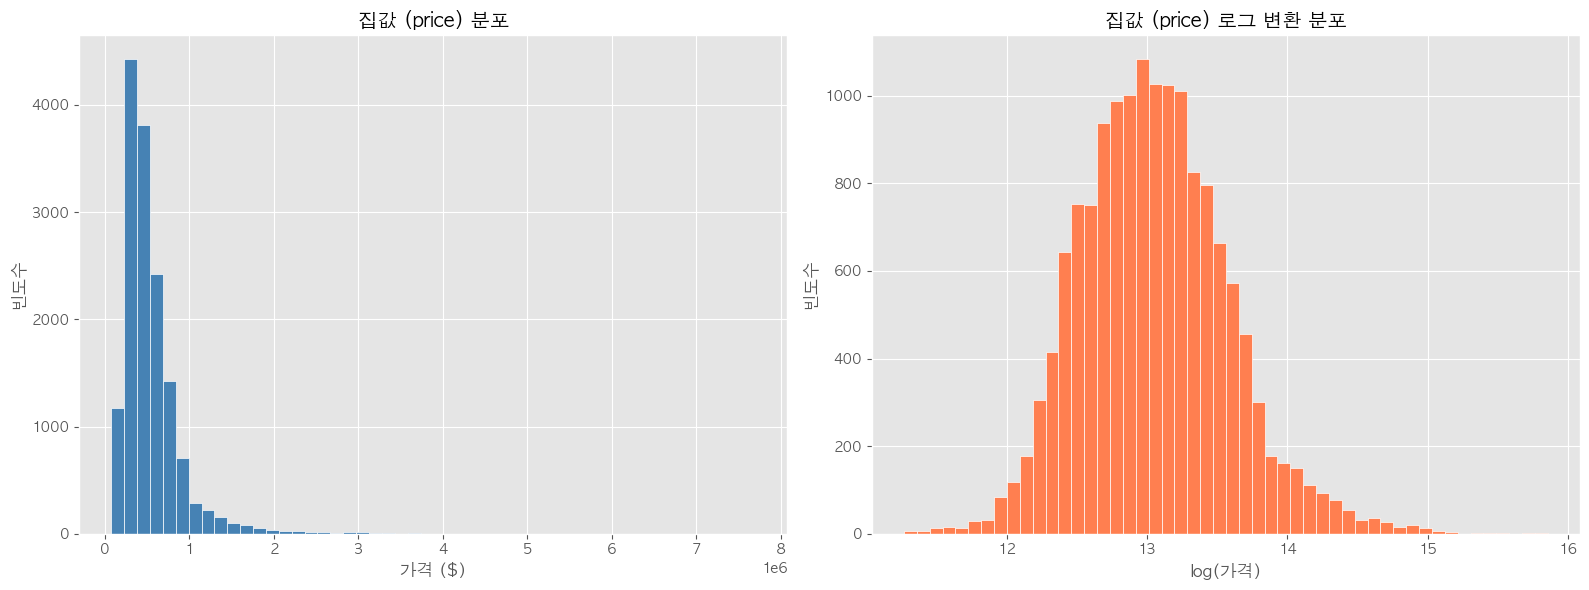

In [8]:
# 집값 분포 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 원본 분포
axes[0].hist(train['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('집값 (price) 분포', fontsize=14)
axes[0].set_xlabel('가격 ($)')
axes[0].set_ylabel('빈도수')

# 오른쪽: 로그 변환한 분포
axes[1].hist(np.log1p(train['price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('집값 (price) 로그 변환 분포', fontsize=14)
axes[1].set_xlabel('log(가격)')
axes[1].set_ylabel('빈도수')

plt.tight_layout()
plt.show()

**관찰 포인트:**

- 왼쪽 그래프: 대부분의 집이 저가에 몰려 있고, 오른쪽으로 긴 꼬리가 있습니다 (오른쪽 치우침)
- 오른쪽 그래프: 로그 변환하면 종 모양(정규분포)에 가까워집니다

> **왜 중요한가?** 많은 ML 모델은 데이터가 정규분포에 가까울 때 더 잘 작동합니다.  
> 로그 변환은 치우친 분포를 정규분포에 가깝게 만드는 기법입니다.

### 3.2 산점도: 주거 면적 vs 집값

산점도는 두 변수 사이의 관계를 보여줍니다.  
면적이 넓으면 집값이 비쌀까요? 확인해봅시다.

> DevOps 비유: CPU 코어 수와 처리 성능(TPS)의 관계를 산점도로 보는 것과 같습니다.

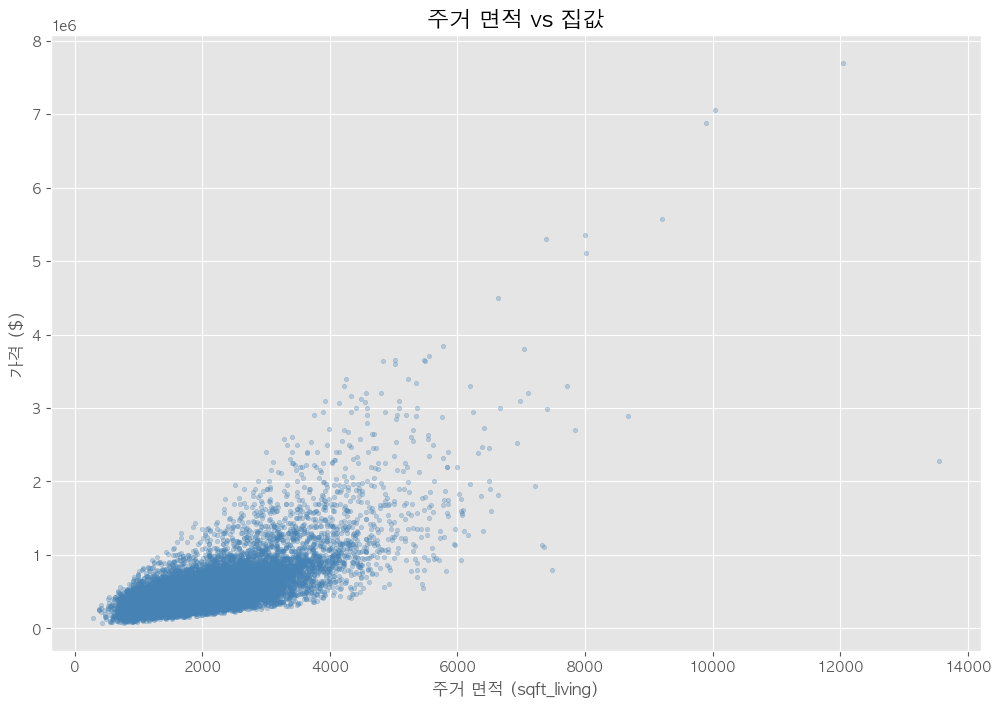

In [9]:
# 주거 면적(sqft_living) vs 집값(price) 산점도
plt.figure(figsize=(12, 8))
plt.scatter(train['sqft_living'], train['price'], 
            alpha=0.3,  # 투명도 (겹치는 점을 구분하기 위해)
            s=10,       # 점 크기
            color='steelblue')

plt.title('주거 면적 vs 집값', fontsize=16)
plt.xlabel('주거 면적 (sqft_living)', fontsize=12)
plt.ylabel('가격 ($)', fontsize=12)
plt.show()

**관찰 포인트:**

- 전반적으로 면적이 클수록 가격이 높은 **양의 상관관계**가 보입니다
- 하지만 같은 면적이라도 가격 차이가 큽니다 (위치, 컨디션 등 다른 요인의 영향)
- 오른쪽 아래에 **이상치**가 보일 수 있습니다: 면적은 매우 큰데 가격이 낮은 경우

> **생각해보기**: 오른쪽 하단의 이상치는 어떤 집일까요? 면적이 12,000 sqft 이상인데 가격이 300만 달러 미만인 경우를 찾아보세요.

### 3.3 이상치 확인 및 제거

산점도에서 발견한 이상치를 실제로 확인하고 제거합니다.

In [10]:
# 이상치 후보 확인: 면적 > 12000 sqft이면서 가격 < 300만 달러
outliers = train[(train['sqft_living'] > 12000) & (train['price'] < 3000000)]
print(f'이상치 후보: {len(outliers)}건')
outliers[['id', 'price', 'sqft_living', 'bedrooms', 'bathrooms', 'grade']]

이상치 후보: 1건


,id,price,sqft_living,bedrooms,bathrooms,grade
8912,8912,2280000.0,13540,7,8.0,12


In [11]:
# 이상치 제거
print(f'제거 전 데이터 수: {len(train)}')

train_clean = train[~((train['sqft_living'] > 12000) & (train['price'] < 3000000))].reset_index(drop=True)

print(f'제거 후 데이터 수: {len(train_clean)}')
print(f'제거된 데이터 수: {len(train) - len(train_clean)}')

제거 전 데이터 수: 15035
제거 후 데이터 수: 15034
제거된 데이터 수: 1


### 3.4 박스플롯: zipcode별 가격 분포

박스플롯(상자 수염 그림)은 데이터의 분포를 한눈에 보여줍니다.

```
    ┌─────┐
    │     │  ← 25% ~ 75% 범위 (IQR)
────┼─────┼────  ← 중앙값 (50%)
    │     │
    └─────┘
  ──┤     ├──  ← 수염 (정상 범위)
    o          ← 이상치
```

상위 10개 zipcode에 대한 가격 분포를 비교해봅시다.

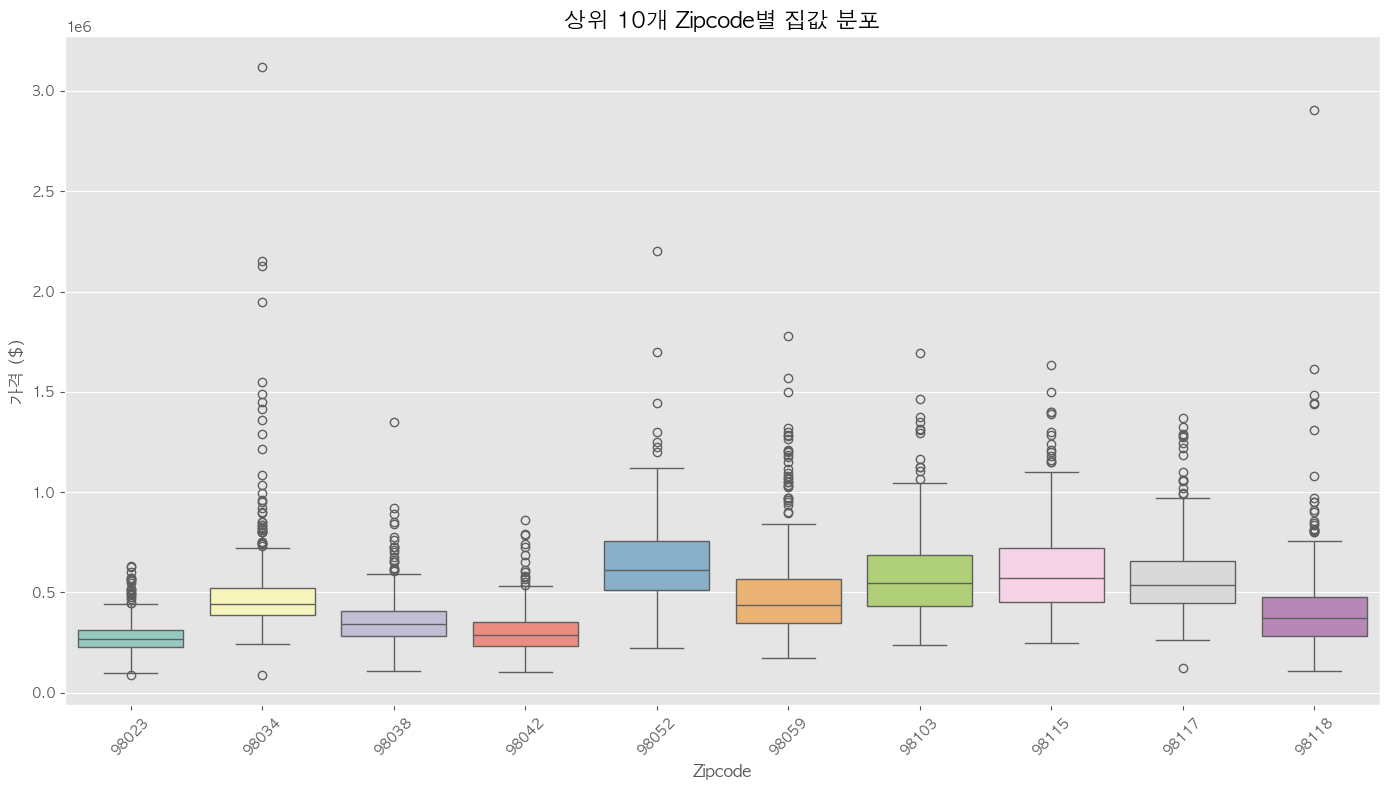

In [12]:
# 데이터가 많은 상위 10개 zipcode 선택
top_zipcodes = train_clean['zipcode'].value_counts().head(10).index

# 해당 zipcode 데이터만 필터링
zip_data = train_clean[train_clean['zipcode'].isin(top_zipcodes)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='zipcode', y='price', data=zip_data, 
            hue='zipcode',            # hue에 x 변수를 지정
            order=sorted(top_zipcodes),  # zipcode 정렬
            palette='Set3',
            legend=False)

plt.title('상위 10개 Zipcode별 집값 분포', fontsize=16)
plt.xlabel('Zipcode', fontsize=12)
plt.ylabel('가격 ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**관찰 포인트:**

- 같은 도시 안에서도 zipcode(지역)에 따라 집값 차이가 큽니다
- 일부 지역은 가격대가 높고, 일부는 낮습니다
- 각 박스의 높이(IQR)가 다르면 해당 지역의 가격 편차가 크다는 뜻입니다

> **생각해보기**: 가장 비싼 zipcode는 어디인가요? 가격 편차가 가장 큰 지역은?

### 3.5 지도 시각화: 위도/경도 기반 가격 분포

위도(lat)와 경도(long) 정보를 활용하여 지도 위에 집값을 표시합니다.  
색상으로 가격을 표현하면 어떤 지역이 비싼지 한눈에 파악할 수 있습니다.

> DevOps 비유: CDN 노드별 응답 시간을 세계 지도 위에 색상으로 표시하는 것과 비슷합니다.

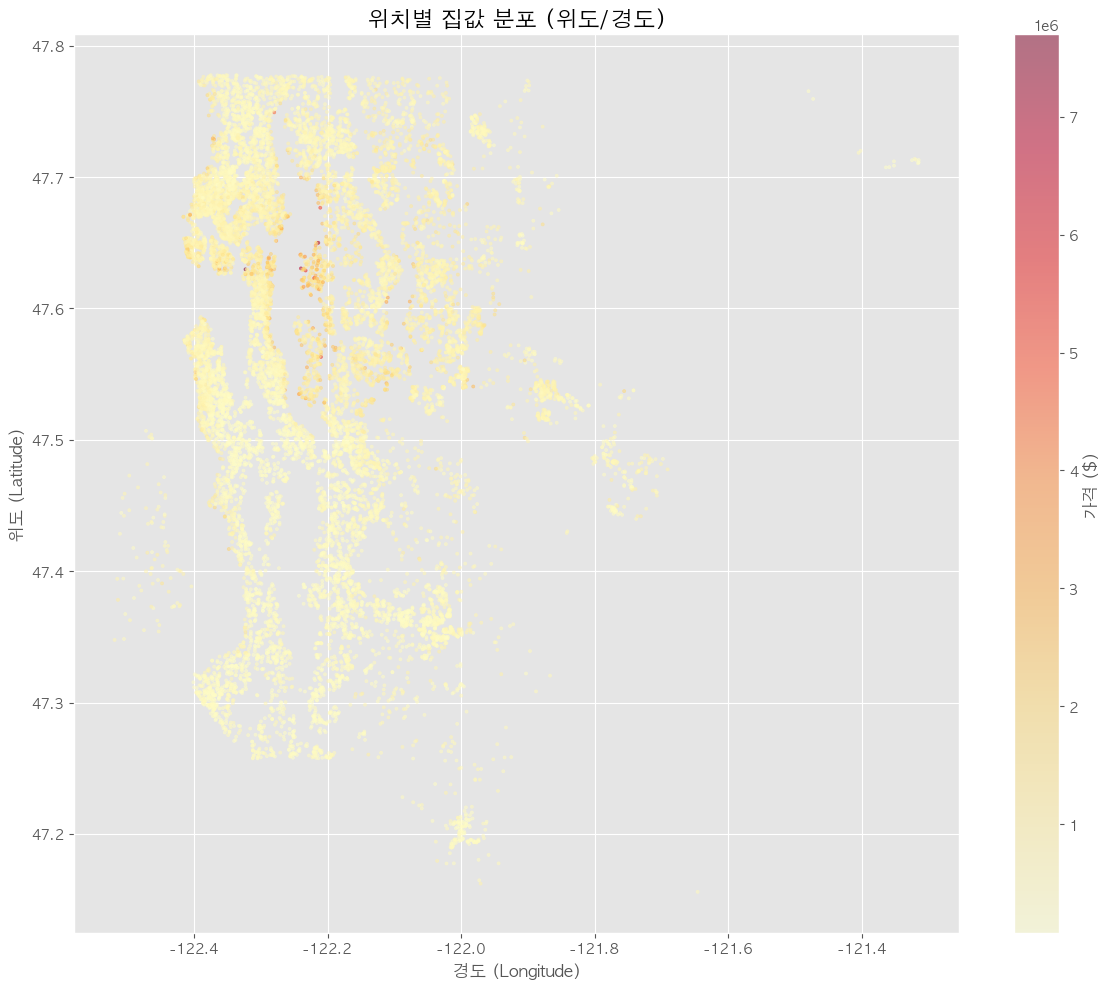

In [13]:
# 위도/경도 기반 집값 시각화
plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    train_clean['long'],      # x축: 경도
    train_clean['lat'],       # y축: 위도
    c=train_clean['price'],   # 색상: 가격
    cmap='YlOrRd',            # 색상 맵 (노랑 → 빨강)
    alpha=0.5,                # 투명도
    s=5                       # 점 크기
)

plt.colorbar(scatter, label='가격 ($)')
plt.title('위치별 집값 분포 (위도/경도)', fontsize=16)
plt.xlabel('경도 (Longitude)', fontsize=12)
plt.ylabel('위도 (Latitude)', fontsize=12)
plt.tight_layout()
plt.show()

**관찰 포인트:**

- 빨간색이 진한 곳이 집값이 비싼 지역입니다
- 특정 지역에 비싼 집들이 밀집해 있는 것을 확인할 수 있습니다
- 위치(location)가 집값에 매우 중요한 요소임을 시각적으로 알 수 있습니다

> **인사이트**: 부동산에서 "위치, 위치, 위치"라는 말이 데이터로도 확인됩니다.

### 3.6 상관관계 히트맵

각 변수들이 집값(price)과 얼마나 관련이 있는지 상관계수로 확인합니다.

- **상관계수 1.0**: 완벽한 양의 상관 (A가 오르면 B도 오름)
- **상관계수 0.0**: 관련 없음
- **상관계수 -1.0**: 완벽한 음의 상관 (A가 오르면 B가 내림)

In [14]:
# price와의 상관계수 계산 (숫자형 컬럼만)
numeric_cols = train_clean.select_dtypes(include=[np.number]).columns
correlations = train_clean[numeric_cols].corr()['price'].sort_values(ascending=False)

print('=== price와의 상관계수 (높은 순) ===')
print(correlations)

=== price와의 상관계수 (높은 순) ===
price            1.000000
sqft_living      0.703159
grade            0.666852
sqft_above       0.607865
sqft_living15    0.585892
bathrooms        0.524500
view             0.399885
bedrooms         0.322828
sqft_basement    0.320548
lat              0.301589
waterfront       0.265959
floors           0.261978
yr_renovated     0.140976
sqft_lot         0.094873
sqft_lot15       0.084298
yr_built         0.047031
condition        0.039965
long             0.023064
id               0.020814
zipcode         -0.051390
Name: price, dtype: float64


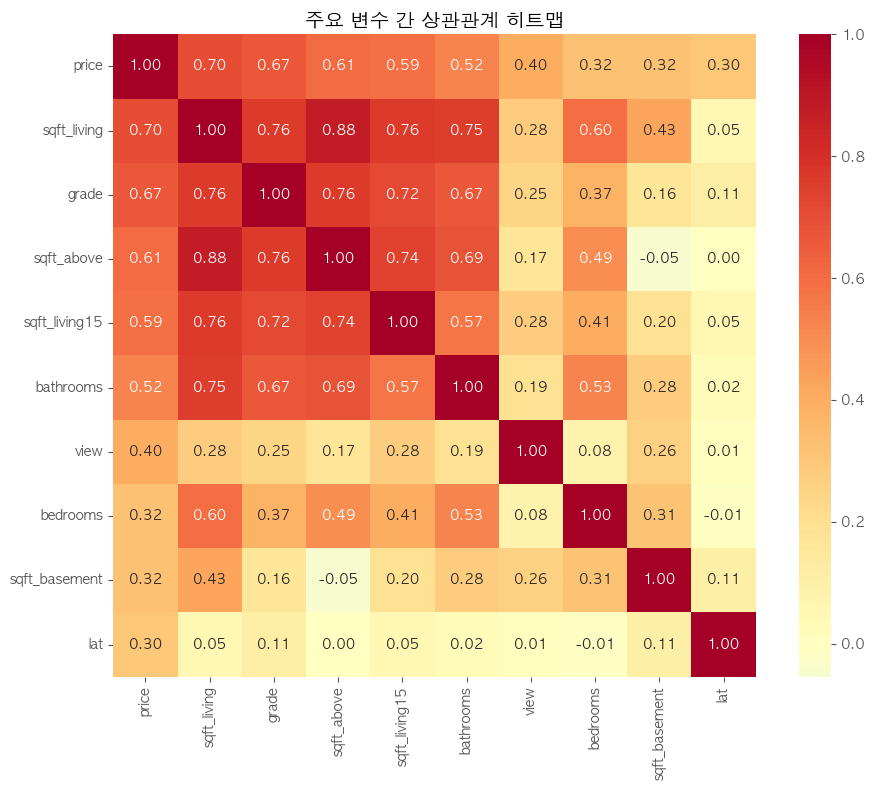

In [15]:
# 상관관계 히트맵 (주요 변수만)
# price와 상관계수가 높은 상위 10개 변수 선택
top_corr_cols = correlations.head(10).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_clean[top_corr_cols].corr(),
    annot=True,       # 숫자 표시
    fmt='.2f',        # 소수점 2자리
    cmap='RdYlBu_r',  # 색상 맵
    center=0,         # 0을 중심으로 색상 배치
    square=True       # 정사각형 셀
)
plt.title('주요 변수 간 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

**관찰 포인트:**

- `sqft_living`(주거 면적)이 가격과 가장 높은 상관관계를 보입니다
- `grade`(건축 품질), `sqft_above`(지상 면적)도 가격과 강한 양의 상관관계가 있습니다
- `sqft_living`과 `sqft_above`는 서로 상관관계가 높습니다 (다중공선성)

> **DevOps 비유**: CPU 사용률과 메모리 사용률이 함께 올라가는 것처럼,  
> 주거 면적과 지상 면적도 함께 증가하는 경향이 있습니다.

### 3.7 데이터 전처리: train/test 통합

나중에 Feature Engineering(특성 공학)을 할 때, train과 test에 동일한 처리를 적용해야 합니다.  
미리 두 데이터를 합쳐놓으면 편리합니다.

In [16]:
# train/test 데이터 합치기
train_copy = train_clean.copy()
train_copy['data'] = 'train'  # 출처 표시

test_copy = test.copy()
test_copy['data'] = 'test'
test_copy['price'] = np.nan   # test에는 price가 없으므로 NaN 처리

# 두 데이터 합치기
data = pd.concat([train_copy, test_copy], sort=False).reset_index(drop=True)

# 불필요한 컬럼 정리
data.drop('date', axis=1, inplace=True)       # 날짜는 사용하지 않음
data['zipcode'] = data['zipcode'].astype(str)  # zipcode를 문자열로 변환

print(f'합친 데이터 크기: {data.shape}')
print(f'train: {len(data[data["data"] == "train"])}건')
print(f'test:  {len(data[data["data"] == "test"])}건')

합친 데이터 크기: (21502, 21)
train: 15034건
test:  6468건


> **왜 합치나요?**  
> 나중에 "침실 수가 3이면 1, 아니면 0"같은 변환을 할 때,  
> train에만 적용하고 test에 빼먹는 실수를 방지하기 위해서입니다.  
> `data` 컬럼으로 train/test를 구분할 수 있습니다.

---

## Session 1 요약

### 오늘 배운 것

| 주제 | 핵심 내용 |
|------|----------|
| ML이란? | 데이터에서 패턴을 찾아 예측하는 기술 |
| 문제 유형 | 이 프로젝트는 회귀 문제 (연속적인 숫자 예측) |
| 학습 유형 | 지도학습(정답 있음) vs 비지도학습(정답 없음) |
| 데이터 유형 | 정형(테이블) vs 비정형(이미지, 텍스트) — 비즈니스 핵심은 정형 데이터 |
| 데이터 중요성 | 모델보다 문제 정의와 데이터 품질이 핵심 |
| 평가 지표 | RMSE - 낮을수록 좋음. 모델은 손실 함수를 최소화하며 학습 |
| EDA | 데이터를 시각화하고 이해하는 과정 |
| 이상치 | 비정상 데이터를 찾아 제거 |
| 상관관계 | sqft_living, grade가 price와 가장 관련 높음 |

### 다음 Session 예고

**Session 2: Feature Engineering (특성 공학)**
- 기존 데이터에서 새로운 변수를 만들어 모델 성능을 높이는 방법
- 예: 건축 연도 → 건물 나이, zipcode → 지역 평균 가격